In [1]:
# Biblioteca
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

In [4]:
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data() #carregamento os dados

x_train, x_test = x_train / 255.0, x_test / 255.0 # é normalizado de 0 até 1
y_train, y_test = y_train.flatten(), y_test.flatten() #transforma em um vetor
print(x_train.shape,  y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1984s 12us/step
(50000, 32, 32, 3) (50000,)


In [6]:
# Numeros de classes
K = len(set(y_train))
print("Número de classes: ", K)

Número de classes:  10


In [8]:
i = Input(shape=x_train[0].shape) # camada de entrada

x = Conv2D(32, (3,3), activation='relu', padding='same') (i)
x = BatchNormalization() (x)
x = Conv2D(32, (3,3), activation='relu', padding='same') (x)
x = BatchNormalization() (x) # normaliza os dados
x = MaxPooling2D() (x) # diminui a imagem

x = Conv2D(64, (3,3), activation='relu', padding='same') (x)
x = BatchNormalization() (x)
x = Conv2D(64, (3,3), activation='relu', padding='same') (x)
x = BatchNormalization() (x) # normaliza os dados
x = MaxPooling2D() (x) # diminui a imagem

x = Conv2D(128, (3,3), activation='relu', padding='same') (x)
x = BatchNormalization() (x)
x = Conv2D(128, (3,3), activation='relu', padding='same') (x)
x = BatchNormalization() (x) # normaliza os dados
x = MaxPooling2D() (x) # diminui a imagem

x = Flatten() (x)
x = Dropout(0.2) (x) # evitar overffiting
x = Dense(1024, activation='relu') (x)
x = Dropout(0.2) (x) # evitar overffiting

x = Dense(K, activation='softmax') (x) # camada de saida
model = Model(i,x)


In [9]:
# Compilando e treinando o modelo
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
r = model.fit(x_train,y_train, validation_data=(x_test, y_test), epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 507s 320ms/step - accuracy: 0.5487 - loss: 1.3038 - val_accuracy: 0.6564 - val_loss: 0.9747
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 499s 320ms/step - accuracy: 0.7046 - loss: 0.8533 - val_accuracy: 0.7106 - val_loss: 0.8539
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 515s 330ms/step - accuracy: 0.7616 - loss: 0.6955 - val_accuracy: 0.7371 - val_loss: 0.7952
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 492s 315ms/step - accuracy: 0.7963 - loss: 0.5925 - val_accuracy: 0.7569 - val_loss: 0.7620
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 513s 328ms/step - accuracy: 0.8257 - loss: 0.5052 - val_accuracy: 0.7472 - val_loss: 0.7435


In [10]:
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True)
train_generator = data_generator.flow(x_train, y_train, batch_size)
steps_per_epoch = x_train.shape[0] // batch_size
r = model.fit(train_generator, validation_data=(x_test, y_test), steps_per_epoch=steps_per_epoch, epochs=5)

Epoch 1/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 537s 344ms/step - accuracy: 0.7695 - loss: 0.6834 - val_accuracy: 0.7808 - val_loss: 0.6925
Epoch 2/5
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 6:53 265ms/step - accuracy: 0.8438 - loss: 0.6697

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.8438 - loss: 0.6697 - val_accuracy: 0.7776 - val_loss: 0.7055
Epoch 3/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 520s 333ms/step - accuracy: 0.7890 - loss: 0.6192 - val_accuracy: 0.7898 - val_loss: 0.6195
Epoch 4/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8125 - loss: 0.5039 - val_accuracy: 0.7832 - val_loss: 0.6361
Epoch 5/5
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 560s 345ms/step - accuracy: 0.8035 - loss: 0.5780 - val_accuracy: 0.7783 - val_loss: 0.6400


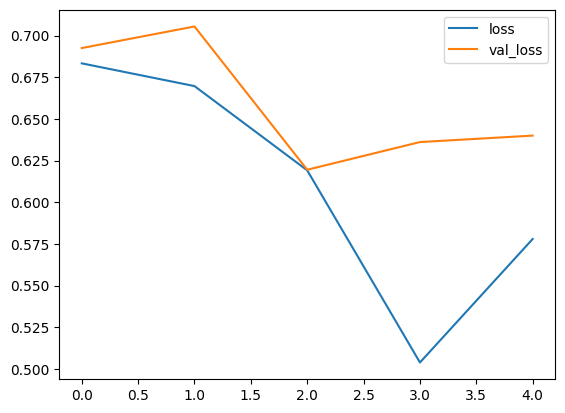

In [13]:
# Grafico de interação do loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

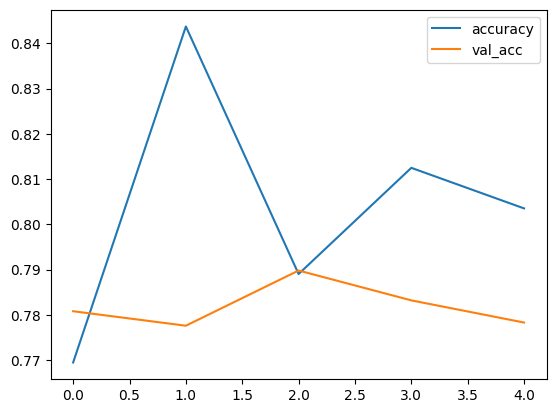

In [14]:
# Grafico de interação da acuracia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step
Confusion matrix, without normalization
[[760  21  29  42  17   1  22   9  41  58]
 [  1 879   0   1   1   1   8   0   5 104]
 [ 46   9 603  57  54  64 127  15   8  17]
 [  6   7  30 539  39 136 171  23  15  34]
 [  8   1  43  38 691  14 130  62   7   6]
 [  4   0  23  91  38 721  78  30   1  14]
 [  3   7  10  13   3   6 951   1   2   4]
 [  2   1  13  22  24  36  23 857   2  20]
 [ 44  33   3   7   0   2  24   2 834  51]
 [  7  31   1   0   1   1   6   2   3 948]]


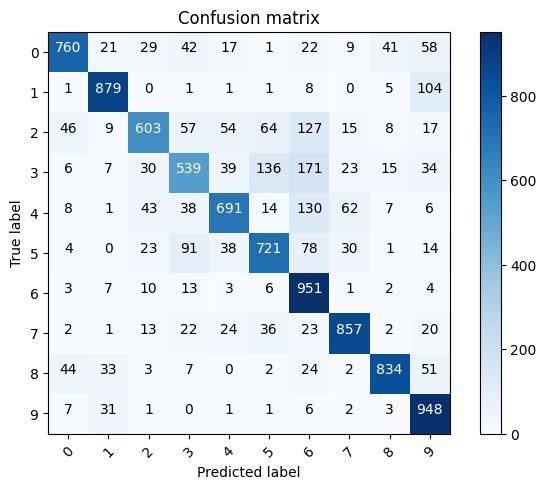

In [15]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # Cor
                          ):

    if normalize: # normalização da matriz
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plot da matriz
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # eixo x
    plt.yticks(tick_marks, classes) # eixo y

    # formatando os números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    # colocando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Criando a predição
p_test = model.predict(x_test).argmax(axis=1)
# Criando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [16]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,189,888 (27.43 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 4,792,662 (18.28 MB)